# EDA

Identifying high level patterns, substructures, missing elements, and flaws in the datasets 

## Loading datasets

In [1]:
# Convert raw csv files into pandas dataframes

import pandas as pd

ALE_RAW = "../data/raw/account_lifecycle_events.csv"
UEM_RAW = "../data/raw/user_engagement_metrics.csv"
SIH_RAW = "../data/raw/support_interaction_history.csv"

ale_df = pd.read_csv(ALE_RAW, parse_dates=['created_timestamp', 'last_activity_timestamp', 'status_change_date', 'contract_end_date'])
uem_df = pd.read_csv(UEM_RAW, parse_dates=['user_created_date', 'last_login_date'])
sih_df = pd.read_csv(SIH_RAW, parse_dates=['created_date', 'resolved_date'])

In [2]:
# Generate sweetviz profiles on the three datasets for quick references 

# import sweetviz as sv
# import os

# ale_report = sv.analyze(ale_df)
# uem_report = sv.analyze(uem_df)
# sih_report = sv.analyze(sih_df)

# ale_report.show_html("../data/profiles/ale_report.html", open_browser=False)
# uem_report.show_html("../data/profiles/uem_report.html", open_browser=False)
# sih_report.show_html("../data/profiles/sih_report.html", open_browser=False)

## Preprocessing

**Timestamps --> Durations**

### Converting timestamps to durations

Confirm all date columns parse to the same dtype across the three datasets before computing durations.

Timestamp columns are converted to integer day offsets relative to a `SNAPSHOT_DATE` anchored to the latest record across the three CSV files. This is the next best alternative to an actual extraction date.

**Sign convention:** `(snapshot_date - col).dt.days`  
- Positive → event is in the past (e.g. account created 400 days ago)  
- Negative → event is in the future (e.g. `days_since_contract_end = -30` means contract ends in 30 days)

In [3]:
# Verify dtype and sample values for every timestamp column across all three datasets

timestamp_cols = {
    'ALE': ['created_timestamp', 'last_activity_timestamp', 'status_change_date', 'contract_end_date'],
    'UEM': ['user_created_date', 'last_login_date'],
    'SIH': ['created_date', 'resolved_date'],
}
frames = {'ALE': ale_df, 'UEM': uem_df, 'SIH': sih_df}

for table, cols in timestamp_cols.items():
    df = frames[table]
    for col in cols:
        sample = df[col].dropna().iloc[0] if df[col].notna().any() else None
        print(f"{table}.{col:35s}  dtype={str(df[col].dtype):20s}  sample={sample}")
    print()

ALE.created_timestamp                    dtype=datetime64[us]        sample=2022-08-17 00:00:00
ALE.last_activity_timestamp              dtype=datetime64[us]        sample=2024-12-21 00:00:00
ALE.status_change_date                   dtype=datetime64[us]        sample=2023-12-17 00:00:00
ALE.contract_end_date                    dtype=datetime64[us]        sample=2024-08-16 00:00:00

UEM.user_created_date                    dtype=datetime64[us]        sample=2022-09-01 00:00:00
UEM.last_login_date                      dtype=datetime64[us]        sample=2024-12-18 00:00:00

SIH.created_date                         dtype=datetime64[us]        sample=2023-02-12 00:00:00
SIH.resolved_date                        dtype=datetime64[us]        sample=2023-02-13 02:03:45.742785



In [4]:
# Create metadata df for timeframe columns based on operational use case
# TODO status_change_date could be a leakage risk since some are scheduled for the future

timestamp_metadata = pd.DataFrame([
    {'field': 'created_timestamp',       'csv_file': 'ale', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'last_activity_timestamp', 'csv_file': 'ale', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'status_change_date',      'csv_file': 'ale', 'forward_looking': True,  'use_for_snapshot': False},  # can record future scheduled changes, leakage risk
    {'field': 'contract_end_date',       'csv_file': 'ale', 'forward_looking': True,  'use_for_snapshot': False},  # no leakage risk, expect negative durations at times
    {'field': 'user_created_date',       'csv_file': 'uem', 'forward_looking': False, 'use_for_snapshot': False},  # creation dates lag activity cutoff so best not to include in snapshot
    {'field': 'last_login_date',         'csv_file': 'uem', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'created_date',            'csv_file': 'sih', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'resolved_date',           'csv_file': 'sih', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
]).set_index('field')
display(timestamp_metadata)

,csv_file,forward_looking,use_for_snapshot
field,,,
created_timestamp,ale,False,True
last_activity_timestamp,ale,False,True
status_change_date,ale,True,False
contract_end_date,ale,True,False
user_created_date,uem,False,False
last_login_date,uem,False,True
created_date,sih,False,True
resolved_date,sih,False,True


In [5]:
# Calculating snapshot date based on 

snapshot_cols = timestamp_metadata[timestamp_metadata['use_for_snapshot']]

SNAPSHOT_DATE = pd.concat([
    ale_df[snapshot_cols[snapshot_cols['csv_file'] == 'ale'].index],
    uem_df[snapshot_cols[snapshot_cols['csv_file'] == 'uem'].index],
    sih_df[snapshot_cols[snapshot_cols['csv_file'] == 'sih'].index]
]).max().max().normalize()

print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

Snapshot date: 2025-01-02


In [6]:
# Observing the min and max range for timestamps to confirm usage in snapshot calculations

max_rows = []
for field, row in timestamp_metadata.iterrows():
    df = frames[row['csv_file'].upper()]
    max_rows.append({
        'field': field,
        'csv_file': row['csv_file'],
        'forward_looking': row['forward_looking'],
        'use_for_snapshot': row['use_for_snapshot'],
        'min_value': df[field].min(),
        'max_value': df[field].max()
    })

max_df = pd.DataFrame(max_rows).set_index('field')
display(max_df)

,csv_file,forward_looking,use_for_snapshot,min_value,max_value
field,,,,,
created_timestamp,ale,False,True,2022-01-01 00:00:00.000000,2024-12-31 00:00:00.000000
last_activity_timestamp,ale,False,True,2024-09-18 00:00:00.000000,2024-12-31 00:00:00.000000
status_change_date,ale,True,False,2022-02-21 00:00:00.000000,2026-04-21 00:00:00.000000
contract_end_date,ale,True,False,2023-01-01 00:00:00.000000,2026-12-31 00:00:00.000000
user_created_date,uem,False,False,2022-01-02 00:00:00.000000,2025-03-30 00:00:00.000000
last_login_date,uem,False,True,2024-07-04 00:00:00.000000,2024-12-31 00:00:00.000000
created_date,sih,False,True,2022-01-04 00:00:00.000000,2025-01-01 00:00:00.000000
resolved_date,sih,False,True,2022-01-05 13:43:15.337997,2025-01-02 20:28:49.046460


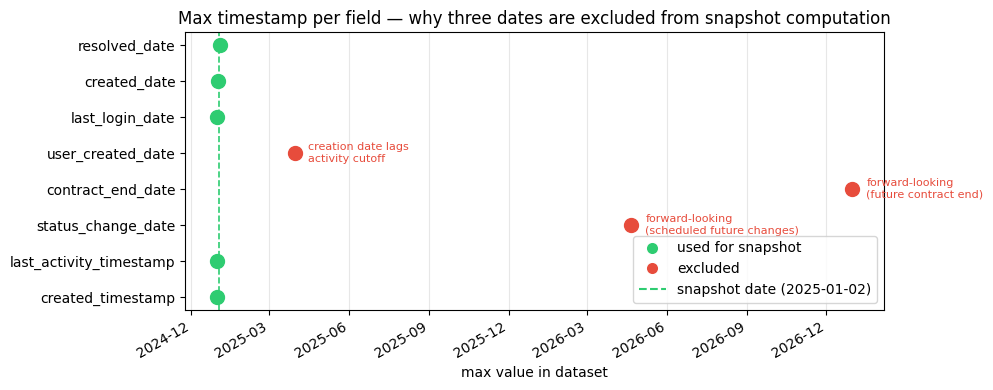

In [7]:
# Plotting max timestamp to visually confirm outliers

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CLUSTER_DATE = pd.Timestamp("2025-01-02")
exclusion_reasons = {
    'status_change_date': 'forward-looking\n(scheduled future changes)',
    'contract_end_date':  'forward-looking\n(future contract end)',
    'user_created_date':  'creation date lags\nactivity cutoff',
}

fig, ax = plt.subplots(figsize=(10, 4))

for i, (field, row) in enumerate(max_df.iterrows()):
    color = '#2ecc71' if row['use_for_snapshot'] else '#e74c3c'
    ax.scatter(row['max_value'], i, color=color, s=100, zorder=3)
    if field in exclusion_reasons:
        ax.annotate(
            exclusion_reasons[field],
            xy=(row['max_value'], i),
            xytext=(10, 0), textcoords='offset points',
            va='center', fontsize=8, color='#e74c3c',
        )

ax.axvline(CLUSTER_DATE, color='#2ecc71', linestyle='--', linewidth=1.2, label=f'snapshot date ({CLUSTER_DATE.date()})')

ax.set_yticks(range(len(max_df)))
ax.set_yticklabels(max_df.index)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
ax.set_xlabel('max value in dataset')
ax.set_title('Max timestamp per field — why three dates are excluded from snapshot computation')

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=9, label='used for snapshot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='excluded'),
    Line2D([0], [0], color='#2ecc71', linestyle='--', label=f'snapshot date ({CLUSTER_DATE.date()})'),
]
ax.legend(handles=legend_handles, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

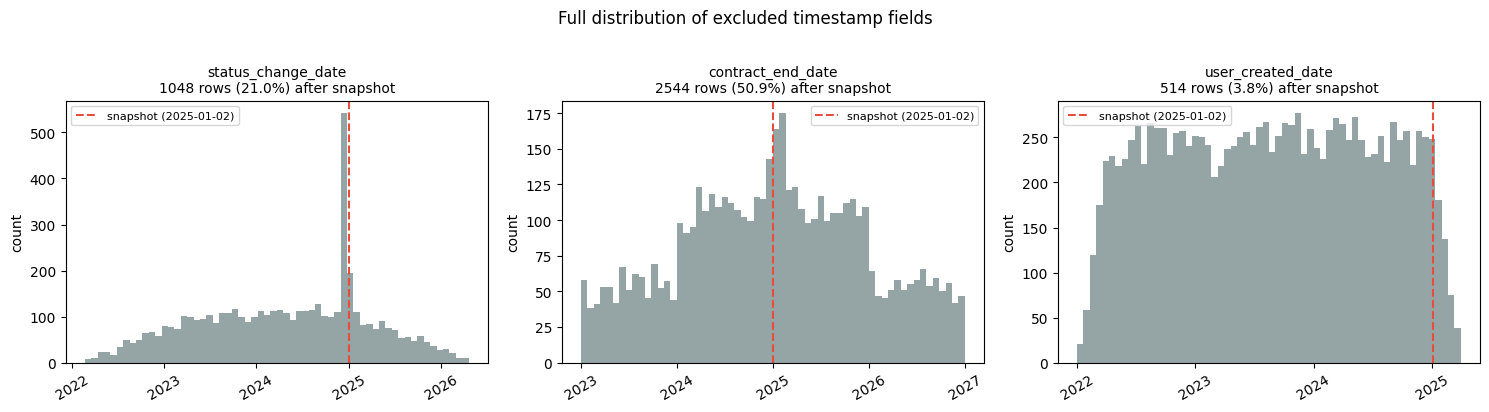

In [8]:
# Plotting distribution of excluded fields to show future events
# TODO the plot for status_change_date is anomalistic, lots of changes around snapshot date

excluded_meta = timestamp_metadata[timestamp_metadata['use_for_snapshot'] == False]

excluded_fields = {
    field: frames[row['csv_file'].upper()][field]
    for field, row in excluded_meta.iterrows()
}

fig, axes = plt.subplots(1, len(excluded_fields), figsize=(15, 4), sharey=False)

for ax, (field, series) in zip(axes, excluded_fields.items()):
    non_null = series.dropna()
    ax.hist(non_null, bins=60, color='#95a5a6', edgecolor='none')
    ax.axvline(SNAPSHOT_DATE, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'snapshot ({SNAPSHOT_DATE.date()})')
    future_count = (non_null > SNAPSHOT_DATE).sum()
    future_pct = future_count / len(non_null) * 100
    ax.set_title(f'{field}\n{future_count} rows ({future_pct:.1f}%) after snapshot', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.set_ylabel('count')

plt.suptitle('Full distribution of excluded timestamp fields', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Function to convert timestamps in data to durations (in days), mutating the df in-place

def timestamps_to_durations(df, column_map, reference_date):
    """
    Add signed integer day-offset columns to df in-place and drop the source timestamp columns.

    column_map: {src_col: dst_col}  e.g. {'created_timestamp': 'days_since_creation'}
    reference_date: pd.Timestamp — the "as-of" date; use SNAPSHOT_DATE, not today.
    """
    for src_col, dst_col in column_map.items():
        df[dst_col] = (reference_date - df[src_col]).dt.days

In [10]:
ale_column_map = {
    'created_timestamp':       'days_since_creation',
    'last_activity_timestamp': 'days_since_last_activity',
    'contract_end_date':       'days_since_contract_end',   # negative = contract hasn't ended yet
    'status_change_date':      'days_since_status_change',  # spike near snapshot — see next cell
}

uem_column_map = {
    'last_login_date':   'days_since_last_login',
    'user_created_date': 'days_since_user_creation',
}

sih_column_map = {
    'created_date':  'days_since_ticket_creation',
    'resolved_date': 'days_since_resolution',
}

timestamps_to_durations(ale_df, ale_column_map, SNAPSHOT_DATE)
timestamps_to_durations(uem_df, uem_column_map, SNAPSHOT_DATE)
timestamps_to_durations(sih_df, sih_column_map, SNAPSHOT_DATE)

display(ale_df[list(ale_column_map.values())].head(3))
display(uem_df[list(uem_column_map.values())].head(3))
display(sih_df[list(sih_column_map.values())].head(3))

,days_since_creation,days_since_last_activity,days_since_contract_end,days_since_status_change
0,869,12,139,382
1,1046,11,316,731
2,534,23,169,157


,days_since_last_login,days_since_user_creation
0,15,854
1,6,856
2,11,797


,days_since_ticket_creation,days_since_resolution
0,690,688
1,342,340
2,394,392


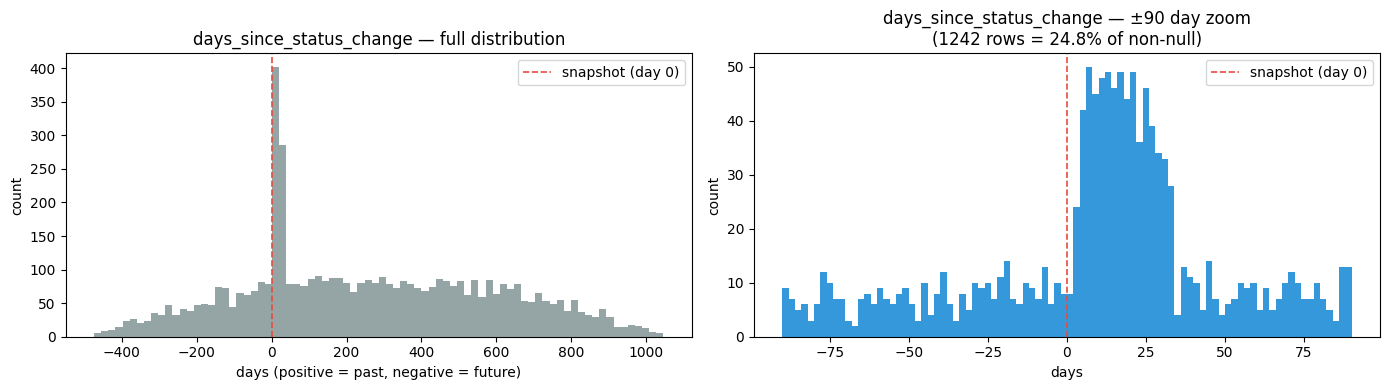

count    5000.000000
mean      253.638800
std       332.683659
min      -474.000000
25%        11.000000
50%       213.000000
75%       515.250000
max      1046.000000

Rows at exactly day 0 (status_change = snapshot date): 3
Rows within ±7 days of snapshot:                       155
Rows within ±30 days of snapshot:                      766


In [11]:
# Investigate days_since_status_change — cell-11 flagged an anomalistic spike near the snapshot date
# Hypothesis: many accounts have a status_change_date clustered just before/at the snapshot,
# which would make this column a near-constant near 0 for a large fraction of rows — weak signal.

col = 'days_since_status_change'
series = ale_df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(series, bins=80, color='#95a5a6', edgecolor='none')
axes[0].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='snapshot (day 0)')
axes[0].set_title(f'{col} — full distribution')
axes[0].set_xlabel('days (positive = past, negative = future)')
axes[0].set_ylabel('count')
axes[0].legend()

window = series[(series >= -90) & (series <= 90)]
axes[1].hist(window, bins=90, color='#3498db', edgecolor='none')
axes[1].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='snapshot (day 0)')
axes[1].set_title(f'{col} — ±90 day zoom\n({len(window)} rows = {len(window)/len(series)*100:.1f}% of non-null)')
axes[1].set_xlabel('days')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(series.describe().to_string())
print(f"\nRows at exactly day 0 (status_change = snapshot date): {(series == 0).sum()}")
print(f"Rows within ±7 days of snapshot:                       {((series >= -7) & (series <= 7)).sum()}")
print(f"Rows within ±30 days of snapshot:                      {((series >= -30) & (series <= 30)).sum()}")

### Dropping obvious non-features

Candidate list:

**ALE**
- account_uuid --> signal already encoded by region and days_since_creation

**UEM**
- account_uuid --> redundant (ale)
- user_email --> redundant (1-1 with user_id)

**SIH**
- account_uuid --> redundant (ale)
- org_id --> redundant (ale)
- retention_offer_accepted (>99% false, <1% true) --> (no variance)

In [13]:
# Test whether ale.account_uuid rows are redundant and encoded in other columns

has_uuid = ale_df["account_uuid"].notna()

is_eu        = ale_df["region"] == "EU"
is_post_2023 = ale_df["created_timestamp"] >= pd.Timestamp("2023-01-01")

both_conditions = is_eu & is_post_2023

total_with_uuid     = has_uuid.sum()
match_both          = (has_uuid & both_conditions).sum()
eu_only             = (has_uuid & is_eu & ~is_post_2023).sum()
post_2023_only      = (has_uuid & ~is_eu & is_post_2023).sum()
neither             = (has_uuid & ~is_eu & ~is_post_2023).sum()

print(f"Rows with non-null account_uuid:              {total_with_uuid}")
print(f"  match EU + created >= 2023:                 {match_both}  ({match_both/total_with_uuid*100:.1f}%)")
print(f"  EU only (created before 2023):              {eu_only}  ({eu_only/total_with_uuid*100:.1f}%)")
print(f"  created >= 2023 only (non-EU):              {post_2023_only}  ({post_2023_only/total_with_uuid*100:.1f}%)")
print(f"  neither condition (unexpected):             {neither}  ({neither/total_with_uuid*100:.1f}%)")

Rows with non-null account_uuid:              1071
  match EU + created >= 2023:                 1071  (100.0%)
  EU only (created before 2023):              0  (0.0%)
  created >= 2023 only (non-EU):              0  (0.0%)
  neither condition (unexpected):             0  (0.0%)


In [14]:
# Making drops

ALE_OBVIOUS_DROPS = ['account_uuid']
UEM_OBVIOUS_DROPS = ['account_uuid', 'user_email']
SIH_OBVIOUS_DROPS = ['account_uuid', 'org_id', 'retention_offer_accepted']

ale_df.drop(columns=ALE_OBVIOUS_DROPS, inplace=True)
uem_df.drop(columns=UEM_OBVIOUS_DROPS, inplace=True)
sih_df.drop(columns=SIH_OBVIOUS_DROPS, inplace=True)

### Naive account-level aggregation to build first pass flat table

Default aggregation strategies per column informed by business heuristics

**ALE**
Already at the account level

**UEM**
